In [ ]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
import matplotlib.pyplot as plt
from collections import defaultdict
from pprint import pprint

# Tokenizers
nltk.download('punkt')
nltk.download('punkt_tab')

# POS Tagger (nouvelle version)
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# NER Chunker
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')

# Lexique
nltk.download('words')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Charger l’article
with open('/content/drive/MyDrive/exempleTP5NER.txt', 'r', encoding='utf-8') as file:
    article = file.read()

print(article[:300])  # Afficher les 300 premiers caractères pour vérifier


John Doe is a software engineer at Google in Mountain View, California.
Apple Inc. is headquartered in Cupertino.
The Eiffel Tower is located in Paris, France.
Barack Obama was the 44th President of the United States.
Elon Musk is the CEO of SpaceX and Tesla, which are both based in California.
Micr


In [ ]:
# Tokeniser en phrases
sentences = sent_tokenize(article)

# Tokeniser chaque phrase en mots
token_sentences = [word_tokenize(sent) for sent in sentences]

# Aperçu
token_sentences[:2]


[['John',
  'Doe',
  'is',
  'a',
  'software',
  'engineer',
  'at',
  'Google',
  'in',
  'Mountain',
  'View',
  ',',
  'California',
  '.'],
 ['Apple', 'Inc.', 'is', 'headquartered', 'in', 'Cupertino', '.']]

In [ ]:
pos_sentences = [nltk.pos_tag(sent) for sent in token_sentences]

# Aperçu
pos_sentences[:2]


[[('John', 'NNP'),
  ('Doe', 'NNP'),
  ('is', 'VBZ'),
  ('a', 'DT'),
  ('software', 'NN'),
  ('engineer', 'NN'),
  ('at', 'IN'),
  ('Google', 'NNP'),
  ('in', 'IN'),
  ('Mountain', 'NNP'),
  ('View', 'NNP'),
  (',', ','),
  ('California', 'NNP'),
  ('.', '.')],
 [('Apple', 'NNP'),
  ('Inc.', 'NNP'),
  ('is', 'VBZ'),
  ('headquartered', 'VBN'),
  ('in', 'IN'),
  ('Cupertino', 'NNP'),
  ('.', '.')]]

In [ ]:
chunked_sentences = nltk.ne_chunk_sents(pos_sentences, binary=True)

print("=== ENTITÉS NOMMÉES (binaire) ===")
for sent in chunked_sentences:
    for chunk in sent:
        if hasattr(chunk, "label") and chunk.label() == 'NE':
            print(chunk)

=== ENTITÉS NOMMÉES (binaire) ===
(NE John/NNP Doe/NNP)
(NE Google/NNP)
(NE Mountain/NNP View/NNP)
(NE California/NNP)
(NE Apple/NNP Inc./NNP)
(NE Cupertino/NNP)
(NE Eiffel/NNP Tower/NNP)
(NE Paris/NNP)
(NE France/NNP)
(NE Barack/NNP Obama/NNP)
(NE United/NNP States/NNPS)
(NE Elon/NNP Musk/NNP)
(NE SpaceX/NNP)
(NE Tesla/NNP)
(NE California/NNP)
(NE Microsoft/NNP Corporation/NNP)
(NE Redmond/NNP)
(NE Washington/NNP)
(NE Great/NNP Wall/NNP)
(NE China/NNP)
(NE Nelson/NNP Mandela/NNP)
(NE South/NNP Africa/NNP)
(NE Louvre/NNP Museum/NNP)
(NE Paris/NNP)
(NE Harvard/NNP University/NNP)
(NE Cambridge/NNP)
(NE Massachusetts/NNP)


In [ ]:
chunked_sentences = nltk.ne_chunk_sents(pos_sentences, binary=False)
ner_categories = defaultdict(int)

for sent in chunked_sentences:
    for chunk in sent:
        if hasattr(chunk, 'label'):
            ner_categories[chunk.label()] += 1

# Affichage formaté
print("=== Comptage des entités nommées ===")
pprint(dict(ner_categories))

=== Comptage des entités nommées ===
{'GPE': 14, 'ORGANIZATION': 11, 'PERSON': 9}


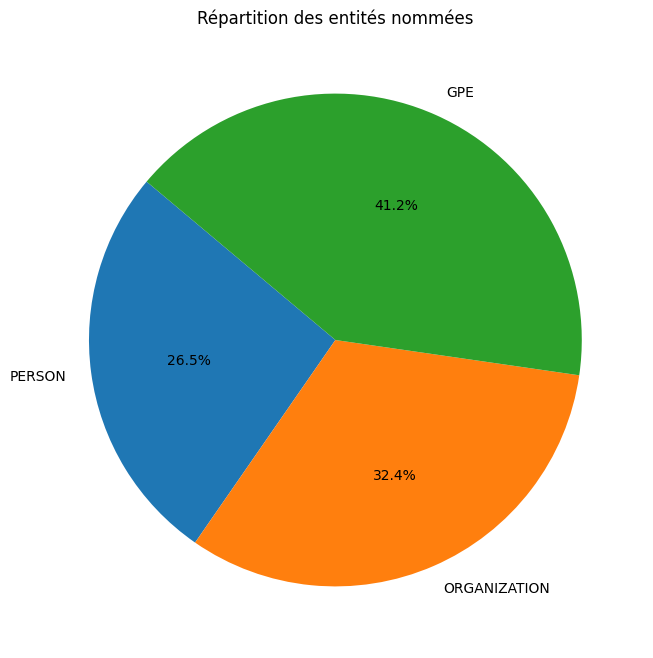

In [ ]:
labels = list(ner_categories.keys())
values = [ner_categories[l] for l in labels]

plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title("Répartition des entités nommées")
plt.show()